## t-SNE Continued

Unsupervised Data Projection 384-dimensional embeddings in 2D, for 10,000 datapoints

sklearn.manifold.TSNE:
https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html

This technique performs non-linear dimensionality reduction by minimizing the Kullback-Leibler divergence between the pairwise similarity distributions of the original high-dimensional space and the target low-dimensional space, minimizing the cost function $$C = \sum_{i \neq j} p_{ij} \log \frac{p_{ij}}{q_{ij}}$$

For practical implementations and the theoretical foundation, consider the following reference:

Visualizing Data using t-SNE (van der Maaten & Hinton, 2008): 

The canonical manuscript introducing the probabilistic framework of the algorithm and its efficacy on various high-dimensional datasets:
https://www.jmlr.org/papers/volume9/vandermaaten08a/vandermaaten08a.pdf

In [1]:
import os
from sentence_transformers import SentenceTransformer # For calculating Embeddings of 10,000 samples.
import pandas as pd
import numpy as np

os.environ["HF_TOKEN"] = " "
df = pd.read_json("../data/processed/mmlu_special_t1.0_n300.jsonl", lines=True)

# Partition of the dataframe into 3 parts
df_s1 = df.iloc[:300]
df_s2 = df.iloc[300:600]
df_s3 = df.iloc[600:]

all_responses_1 = df_s1["model_answer"].to_list()
all_responses_2 = df_s2["model_answer"].to_list()
all_responses_3 = df_s3["model_answer"].to_list()
df_s1["correctness"].describe()

count         300
unique          2
top       correct
freq          232
Name: correctness, dtype: object

In [2]:
# Embedding the (single-question)-responses of a 3 chosen questions in R^384
model = SentenceTransformer("all-MiniLM-L6-v2")
emb_E1 = model.encode(all_responses_1, batch_size=300, normalize_embeddings=True) # E.shape = (300, 384)
emb_E2 = model.encode(all_responses_2, batch_size=300, normalize_embeddings=True) # E.shape = (300, 384)
emb_E3 = model.encode(all_responses_3, batch_size=300, normalize_embeddings=True) # E.shape = (300, 384)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Computing features and t-SNE …
  Question E1                                    Hsem=5.099  Dcos=0.157  K=94  y_mean=0.227  (22.7% hallucinated)  perplexity=30
  Question E2                                    Hsem=5.835  Dcos=0.184  K=125  y_mean=0.623  (62.3% hallucinated)  perplexity=30
  Question E3                                    Hsem=6.891  Dcos=0.226  K=175  y_mean=0.803  (80.3% hallucinated)  perplexity=30

── Hallucination probability summary ──────────────────────────────────
  Question                                       y_mean (halluc rate)  label
  ─────────────────────────────────────────────  ────────────────  ────────────────────
  Question E1                                             0.227   correct
  Question E2                                             0.623   partial hallucination
  Question E3                                             0.803   heavy hallucination

  Average y_mean across all 3 questions:  0.551  (55.1% hallucinated)
───────────────────────

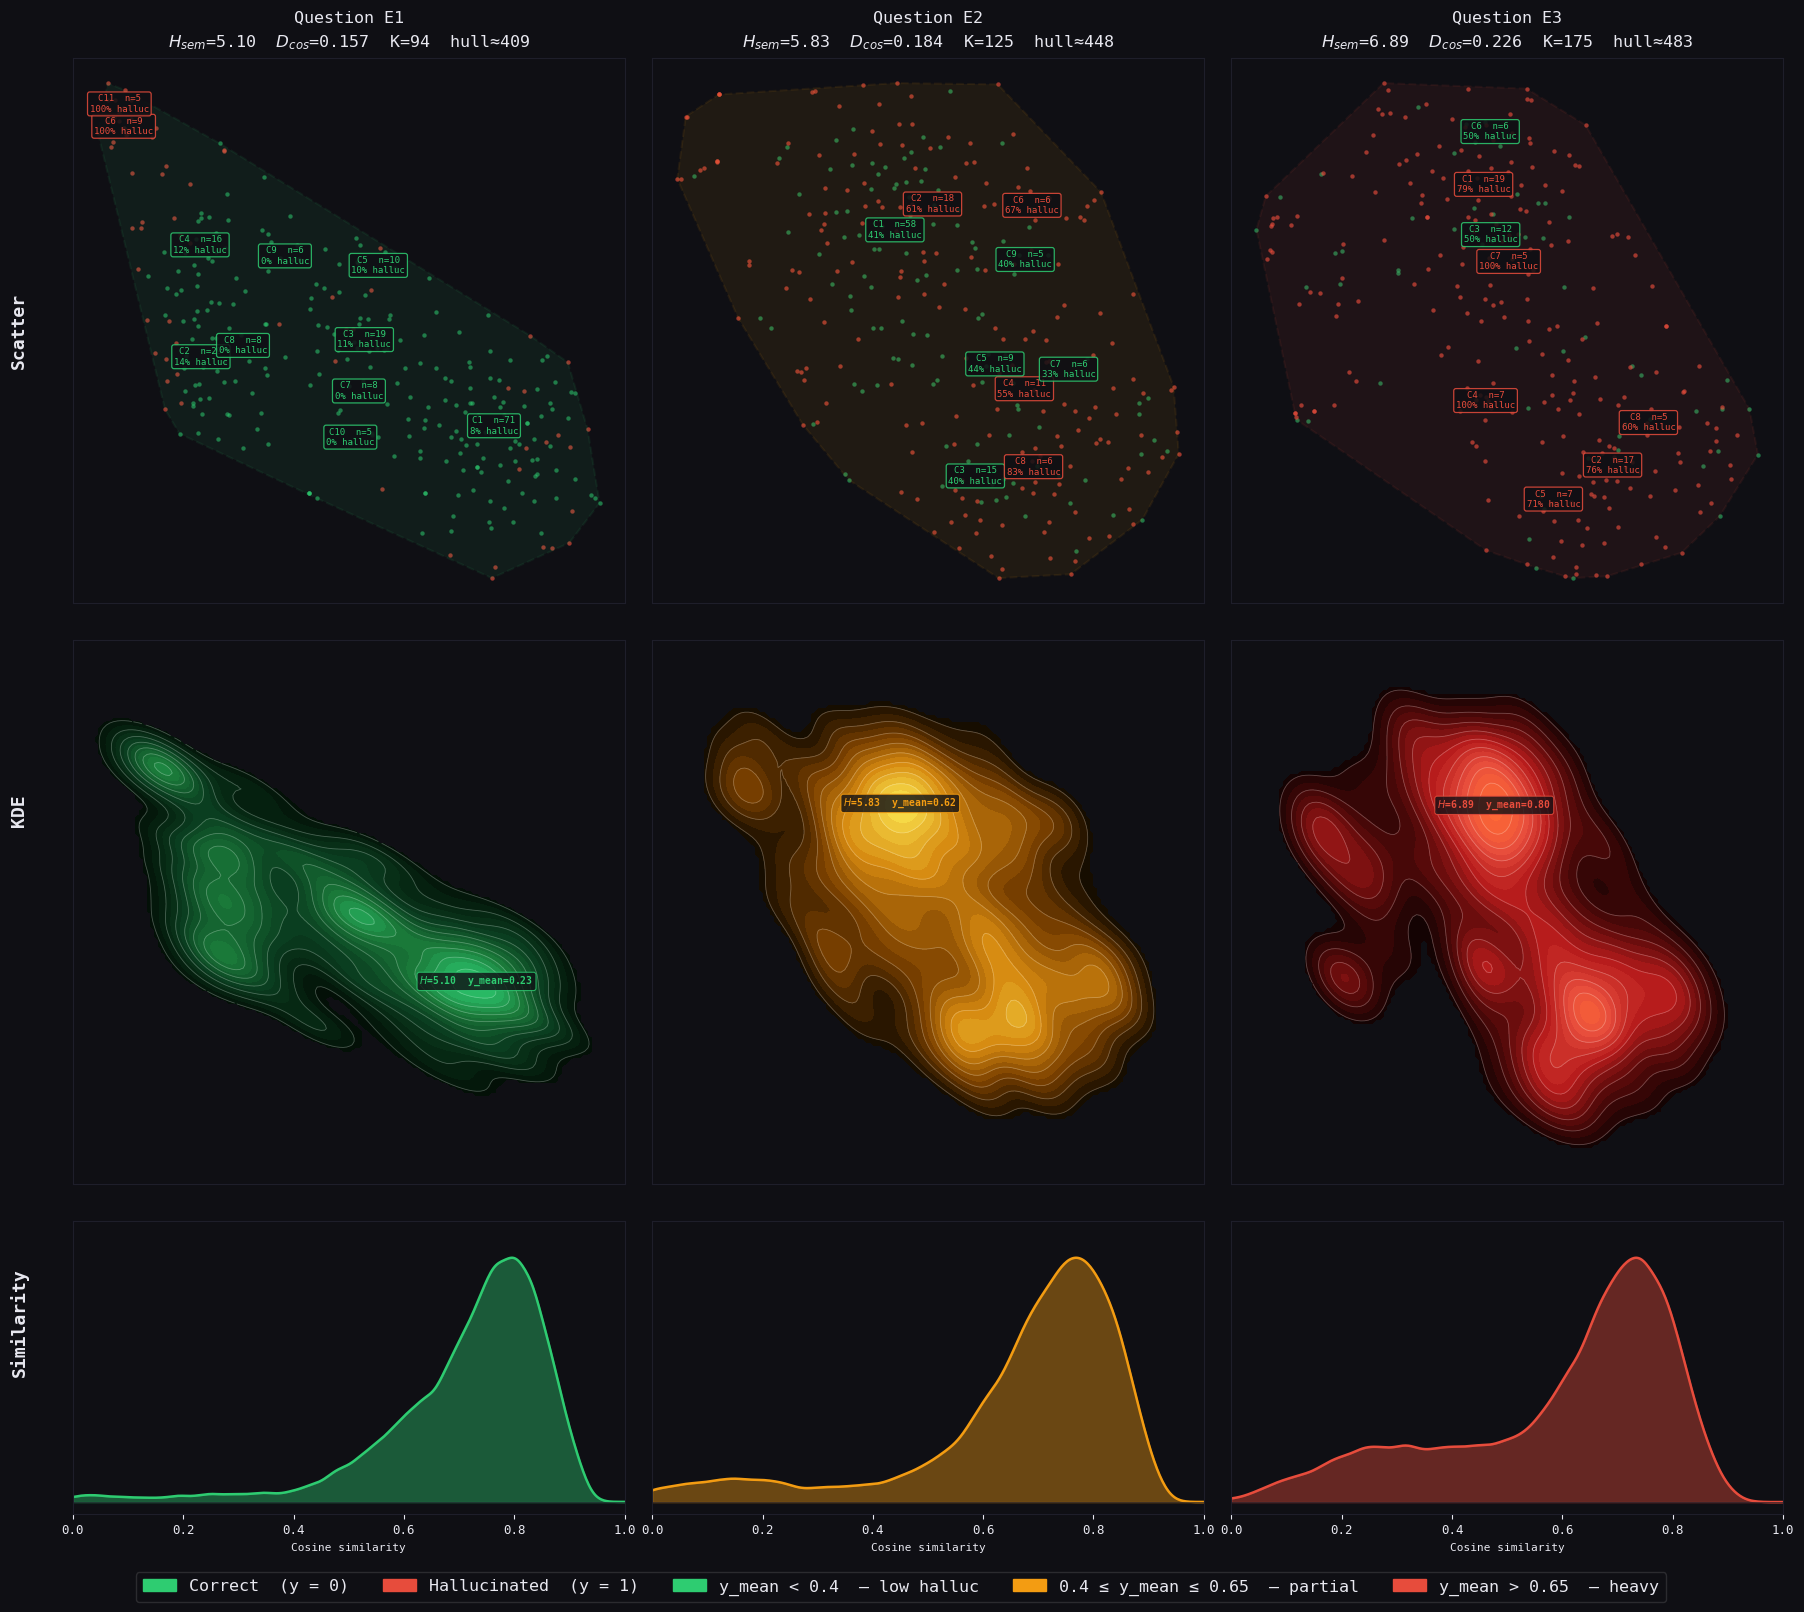


Done.


In [ ]:
"""
Hallucination Geometry Visualisation through t-SNET and KDE plots

"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from scipy.spatial import ConvexHull
from scipy.stats import gaussian_kde
from sklearn.manifold import TSNE
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize
import warnings
warnings.filterwarnings("ignore")

# COLOURS / STYLE
C_CORRECT    = "#2ecc71"   # green
C_HALLUC     = "#e74c3c"   # red
C_PARTIAL    = "#f39c12"   # orange
BG           = "#0f0f14"
GRID         = "#1e1e2a"
TEXT         = "#e8e8f0"
ACCENT       = "#7f8cf7"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor":   BG,
    "axes.edgecolor":   GRID,
    "axes.labelcolor":  TEXT,
    "xtick.color":      TEXT,
    "ytick.color":      TEXT,
    "text.color":       TEXT,
    "grid.color":       GRID,
    "font.family":      "monospace",
    "font.size":        9,
})

import pandas as pd

def df_to_question(label, df, embeddings, perplexity=30):
    """
    Build the question dict used throughout the pipeline.
    """
    # y_mean
    y = (df["correctness"] == "incorrect").astype(int).to_numpy()
    E = normalize(embeddings.astype(np.float32))

    return {"label": label, "E": E, "y": y, "perplexity": perplexity}

questions = [
    df_to_question(
        label      = "Question E1",   
        df         = df_s1,           
        embeddings = emb_E1,          
        perplexity = 30,              
    ),
    df_to_question(
        label      = "Question E2",
        df         = df_s2,
        embeddings = emb_E2,
        perplexity = 30,              
    ),
    df_to_question(
        label      = "Question E3",
        df         = df_s3,
        embeddings = emb_E3,
        perplexity = 30,
    ),
]

SIMILARITY_THRESHOLD = 0.85   # nuclear-sampling

def semantic_entropy(E: np.ndarray, tau: float = SIMILARITY_THRESHOLD) -> tuple:
    """
    Compute Hsem via agglomerative clustering on cosine distance.
    Returns (Hsem, cluster_labels, K)
    """
    N = len(E)
    distance_threshold = 1.0 - tau

    clustering = AgglomerativeClustering(
        n_clusters=None,
        metric="cosine",
        linkage="average",
        distance_threshold=distance_threshold,
    )
    cluster_labels = clustering.fit_predict(E)
    K = cluster_labels.max() + 1

    proportions = np.bincount(cluster_labels) / N

    # Entropy
    Hsem = -sum(p * np.log2(p) for p in proportions if p > 0)
    return float(Hsem), cluster_labels, int(K)


def cosine_dispersion(E: np.ndarray) -> float:
    """
    Dcos 
    """
    centroid = E.mean(axis=0, keepdims=True)           # (1, dim)
    centroid = normalize(centroid)                     # unit-normalise
    sims = cosine_similarity(E, centroid).flatten()    
    return float(np.mean(1.0 - sims))


def pairwise_similarities(E: np.ndarray) -> np.ndarray:
    """Upper-triangle of the N×N cosine similarity matrix."""
    S = cosine_similarity(E)
    idx = np.triu_indices(len(E), k=1)
    return S[idx]


# COMPUTE FEATURES + t-SNE FOR EACH QUESTION
print("Computing features and t-SNE …")

for q in questions:
    E, y = q["E"], q["y"]

    q["Hsem"], q["cluster_labels"], q["K"] = semantic_entropy(E)
    q["Dcos"]   = cosine_dispersion(E)
    q["p_hat"]  = float(y.mean())          # fraction hallucinated
    q["pw_sim"] = pairwise_similarities(E)

    Z = TSNE(
        n_components=2,
        perplexity=q["perplexity"],   # per-question perplexity
        metric="cosine",
        init="pca",
        random_state=42,
        n_jobs=-1,
    ).fit_transform(E)
    q["Z"] = Z

    print(f"  {q['label'].split(chr(10))[0]:45s}  "
          f"Hsem={q['Hsem']:.3f}  Dcos={q['Dcos']:.3f}  "
          f"K={q['K']}  y_mean={q['p_hat']:.3f}  ({q['p_hat']*100:.1f}% hallucinated)"
          f"  perplexity={q['perplexity']}")

# Summary table 
print("\n── Hallucination probability summary ──────────────────────────────────")
print(f"  {'Question':<45}  {'y_mean (halluc rate)':>16}  {'label'}")
print(f"  {'─'*45}  {'─'*16}  {'─'*20}")
for q in questions:
    p = q['p_hat']
    category = ("correct"               if p < 0.4  else
                "partial hallucination"  if p <= 0.65 else
                "heavy hallucination")
    print(f"  {q['label'].split(chr(10))[0]:<45}  {p:>14.3f}   {category}")
avg = np.mean([q['p_hat'] for q in questions])
print(f"\n  Average y_mean across all 3 questions:  {avg:.3f}  ({avg*100:.1f}% hallucinated)")
print("────────────────────────────────────────────────────────────────────────\n")


# HELPER: convex hull patch
def add_hull(ax, points, colour, alpha=0.15, lw=1.4):
    """Draw a filled convex hull around 2-D points."""
    if len(points) < 3:
        return 0.0
    try:
        hull  = ConvexHull(points)
        verts = points[hull.vertices]
        patch = plt.Polygon(verts, closed=True,
                            facecolor=colour, alpha=alpha,
                            edgecolor=colour, linewidth=lw, linestyle="--")
        ax.add_patch(patch)
        return hull.volume          # 2-D "volume" = area
    except Exception:
        return 0.0


# COMBINED FIGURE  —  3 columns (E1, E2, E3)  ×  3 rows
#   Row 0 : Deep-pass scatter  (t-SNE points, convex hull, cluster labels)
#   Row 1 : KDE contour map    (2-D density on t-SNE projection)
#   Row 2 : 1-D pairwise similarity curve  (individual, not stacked)
print("\nRendering combined figure …")

# colormaps and accent colours
CMAPS = {
    "correct": LinearSegmentedColormap.from_list("correct", [
        "#020d05", "#0a3d1f", "#1a7a3a", "#2ecc71"], N=256),
    "partial": LinearSegmentedColormap.from_list("partial", [
        "#0d0800", "#7a4000", "#d68910", "#f9e04b"], N=256),
    "heavy":   LinearSegmentedColormap.from_list("heavy", [
        "#0d0202", "#5c0a0a", "#b71c1c", "#e74c3c", "#ff6b35"], N=256),
}

def question_cmap(p_hat):
    if p_hat < 0.4:  return CMAPS["correct"]
    if p_hat > 0.65: return CMAPS["heavy"]
    return CMAPS["partial"]

def question_colour(p_hat):
    if p_hat < 0.4:  return "#2ecc71"
    if p_hat > 0.65: return "#e74c3c"
    return "#f39c12"

# ── figure layout ─────────────────────────────────────────────────────────────
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(18, 16))
fig.patch.set_facecolor(BG)

gs = GridSpec(3, 3, figure=fig,
              hspace=0.08, wspace=0.05,
              height_ratios=[1.3, 1.3, 0.7],
              left=0.04, right=0.99, top=0.97, bottom=0.06)

axes = [[fig.add_subplot(gs[row, col]) for col in range(3)] for row in range(3)]

SIM_GRID = np.linspace(0.0, 1.0, 400)

for col, q in enumerate(questions):   # original order: E1, E2, E3
    Z      = q["Z"]
    y      = q["y"]
    cl     = q["cluster_labels"]
    colour = question_colour(q["p_hat"])
    cmap   = question_cmap(q["p_hat"])

    # ROW 0: deep-pass scatter
    ax0 = axes[0][col]
    mask_c = y == 0
    mask_h = y == 1
    ax0.scatter(Z[mask_c, 0], Z[mask_c, 1],
                c=C_CORRECT, s=10, alpha=0.55, linewidths=0)
    ax0.scatter(Z[mask_h, 0], Z[mask_h, 1],
                c=C_HALLUC,  s=10, alpha=0.65, linewidths=0)

    hull_colour = (C_CORRECT if q["p_hat"] < 0.4
                   else C_HALLUC if q["p_hat"] > 0.65
                   else C_PARTIAL)
    hull_area = add_hull(ax0, Z, hull_colour, alpha=0.08, lw=1.5)

    # top clusters only
    cluster_sizes = [(k, int(np.sum(cl == k))) for k in range(q["K"])]
    top_clusters  = sorted(cluster_sizes, key=lambda x: -x[1])[:12]
    for rank_c, (k, size) in enumerate(top_clusters):
        if size < 5:
            continue
        idx_k  = np.where(cl == k)[0]
        cx, cy = Z[idx_k, 0].mean(), Z[idx_k, 1].mean()
        frac_h = float(y[idx_k].mean())
        mc = C_HALLUC if frac_h > 0.5 else C_CORRECT
        ax0.annotate(f"C{rank_c+1}  n={size}\n{frac_h*100:.0f}% halluc",
                     xy=(cx, cy), fontsize=6.5, color=mc,
                     ha="center", va="center",
                     bbox=dict(boxstyle="round,pad=0.25",
                               fc=BG, ec=mc, alpha=0.85, lw=0.9))

    ax0.set_title(
        f"{q['label']}\n"
        f"$H_{{sem}}$={q['Hsem']:.2f}  $D_{{cos}}$={q['Dcos']:.3f}  "
        f"K={q['K']}  hull≈{hull_area:.0f}",
        fontsize=12, color=TEXT, pad=8, linespacing=1.6)
    ax0.set_xticks([]); ax0.set_yticks([])
    ax0.set_facecolor(BG)
    for sp in ax0.spines.values(): sp.set_edgecolor(GRID)

    # ROW 1: KDE contour
    ax1 = axes[1][col]
    try:
        kde2d = gaussian_kde(Z.T, bw_method=0.25)
        xmin, xmax = Z[:, 0].min() - 5, Z[:, 0].max() + 5
        ymin, ymax = Z[:, 1].min() - 5, Z[:, 1].max() + 5
        xx, yy = np.mgrid[xmin:xmax:150j, ymin:ymax:150j]
        zz = kde2d(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
        zz_m = np.ma.masked_where(zz < 0.08 * zz.max(), zz)

        ax1.contourf(xx, yy, zz_m, levels=18, cmap=cmap, alpha=1.0)
        ax1.contour( xx, yy, zz_m, levels=8,
                     colors=["#ffffff44"], linewidths=0.6)

        # peak annotation
        peak_idx = np.argmax(zz)
        px, py = xx.ravel()[peak_idx], yy.ravel()[peak_idx]
        ax1.annotate(f"$H$={q['Hsem']:.2f}  y_mean={q['p_hat']:.2f}",
                     xy=(px, py), fontsize=7, color=colour, fontweight="bold",
                     ha="center",
                     bbox=dict(boxstyle="round,pad=0.25",
                               fc=BG, ec=colour, alpha=0.8, lw=0.8))
    except Exception:
        pass

    ax1.set_aspect("equal", adjustable="datalim")
    ax1.set_xticks([]); ax1.set_yticks([])
    ax1.set_facecolor(BG)
    for sp in ax1.spines.values(): sp.set_edgecolor(GRID)

    # ROW 2: 1-D pairwise similarity curve
    ax2 = axes[2][col]
    try:
        kde1d   = gaussian_kde(q["pw_sim"], bw_method=0.08)
        density = kde1d(SIM_GRID)
        density = density / density.max()
    except Exception:f=density = np.zeros_like(SIM_GRID)

    ax2.fill_between(SIM_GRID, 0, density, color=colour, alpha=0.40)
    ax2.plot(SIM_GRID, density, color=colour, lw=1.8)
    ax2.axhline(0, color=GRID, lw=0.5)

    ax2.set_xlim(0, 1)
    ax2.set_ylim(-0.05, 1.15)
    ax2.set_xlabel("Cosine similarity", fontsize=8, color=TEXT)
    ax2.set_yticks([])
    ax2.set_facecolor(BG)
    for sp in ax2.spines.values(): sp.set_edgecolor(GRID)
    ax2.tick_params(colors=TEXT)

# row labels (left margin)
for row_label, y_pos in [("Scatter", 0.80), ("KDE", 0.50), ("Similarity", 0.18)]:
    fig.text(0.005, y_pos, row_label, color=TEXT, fontsize=13,
             va="center", ha="left", rotation=90, fontweight="bold")

# shared legend 
handles_comb = [
    mpatches.Patch(color=C_CORRECT, label="Correct  (y = 0)"),
    mpatches.Patch(color=C_HALLUC,  label="Hallucinated  (y = 1)"),
    mpatches.Patch(color="#2ecc71", label="y_mean < 0.4  — low halluc"),
    mpatches.Patch(color="#f39c12", label="0.4 ≤ y_mean ≤ 0.65  — partial"),
    mpatches.Patch(color="#e74c3c", label="y_mean > 0.65  — heavy"),
]
fig.legend(handles=handles_comb, loc="lower center", ncol=5,
           framealpha=0.15, fontsize=12, bbox_to_anchor=(0.5, 0.0))

plt.show()
print("\nDone.")